In [1]:
import jax
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from coppuccino.hdr import compute_injection_hdr
import corner

%load_ext autoreload
%autoreload 2

### Load feather files for LISA galactic binary from lisacattools

In [2]:
# df = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC2A_00000000_posterior.feather')
# df_inj = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC2A_00000000_injections.feather')

In [3]:
df = pd.read_feather('/Users/aaron/Documents/lisa/project-catalog/data/erebor/posterior_chains/LDC2A_00000000_posterior.feather')
df_inj = pd.read_feather('/Users/aaron/Documents/lisa/project-catalog/data/erebor/injection_matches/LDC2A_00000000_injections.feather')

In [4]:
# df = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_posterior.feather')
# df_inj = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_injections.feather')

### Wrap the injection polarization angle to match prior of global fit

In [5]:
def wrap_polarization_angle(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wrap the polarization angle to be between 0 and pi.
    """
    theta = df["Polarization"].to_numpy().squeeze()
    wrapped = np.abs(np.angle(np.exp(1j * theta)))
    df["Polarization"] = wrapped
    return df

wrap_polarization_angle(df_inj)

,Name,Amplitude,Ecliptic Latitude,Ecliptic Longitude,Frequency,Frequency Derivative,Inclination,Initial Phase,Polarization,SNR,Detached
0,21201135.0,1.280450e-21,0.873553,3.731534,0.000433,1.102740e-19,2.912797,2.511974,2.790672,21.880255,1


### Choose binary parameters to use in the fit

In [6]:
binary_parameters = ['Frequency', 'Amplitude', 'Inclination',
                              'Initial Phase', 'Ecliptic Latitude',
                              'Ecliptic Longitude', 'Polarization',
                              'Frequency Derivative']

samples = df[binary_parameters].to_numpy()
injection_params = df_inj[binary_parameters].to_numpy()

In [7]:
samples

array([[ 4.32824148e-04,  1.31260066e-21,  2.71638318e+00, ...,
         3.69592651e+00,  2.01597404e-01, -4.33616582e-17],
       [ 4.32823185e-04,  1.53176017e-21,  2.78210818e+00, ...,
         3.70603757e+00,  1.13520072e+00, -1.01323282e-17],
       [ 4.32828362e-04,  2.42179042e-21,  2.14258219e+00, ...,
         3.89331258e+00,  9.28179747e-01, -1.54713735e-16],
       ...,
       [ 4.32823912e-04,  1.50556990e-21,  2.85021224e+00, ...,
         3.86997286e+00,  1.84196171e+00, -6.44512904e-18],
       [ 4.32826056e-04,  2.41758356e-21,  2.12796442e+00, ...,
         3.67234024e+00,  4.31001458e-01, -4.51004499e-17],
       [ 4.32824657e-04,  2.07318904e-21,  2.24052704e+00, ...,
         4.00526194e+00,  2.28737072e+00,  8.16820930e-18]],
      shape=(3600, 8))

### Fit the flow and compute 8D HDR of the injected parameters

In [8]:
hdrs, flow = compute_injection_hdr(samples, injection_params, return_flow=True)

 56%|█████▌    | 223/400 [00:17<00:14, 12.39it/s, train=4.77, val=5.41 (Max patience reached)]


### Display full distributional HDR values for each of the 4 injections; HDRs < 1 are within the support of the posterior

In [9]:
hdrs

array([0.95915])

### We can sample the flow and look at how it did

In [10]:
flow_samples, lp = flow.sample_and_log_prob(jax.random.key(42), (len(samples),))

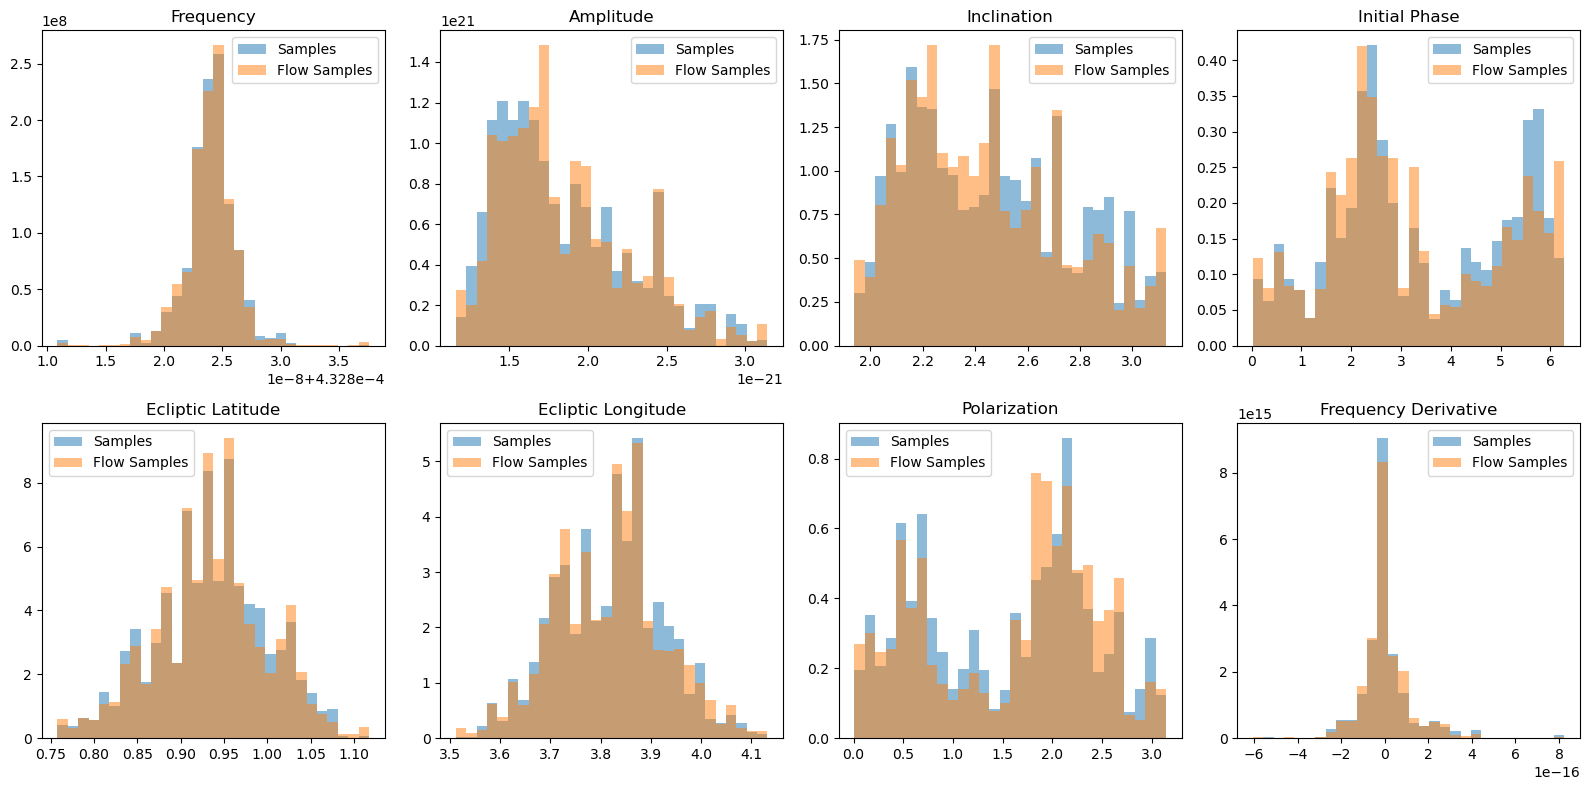

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.hist(samples[:, i], bins=30, density=True, alpha=0.5, label='Samples')
    ax.hist(flow_samples[:, i], bins=30, density=True, alpha=0.5, label='Flow Samples')
    ax.set_title(binary_parameters[i])
    ax.legend()
plt.tight_layout()
plt.show()

### Check the corner plot to make sure we've captured the correlations

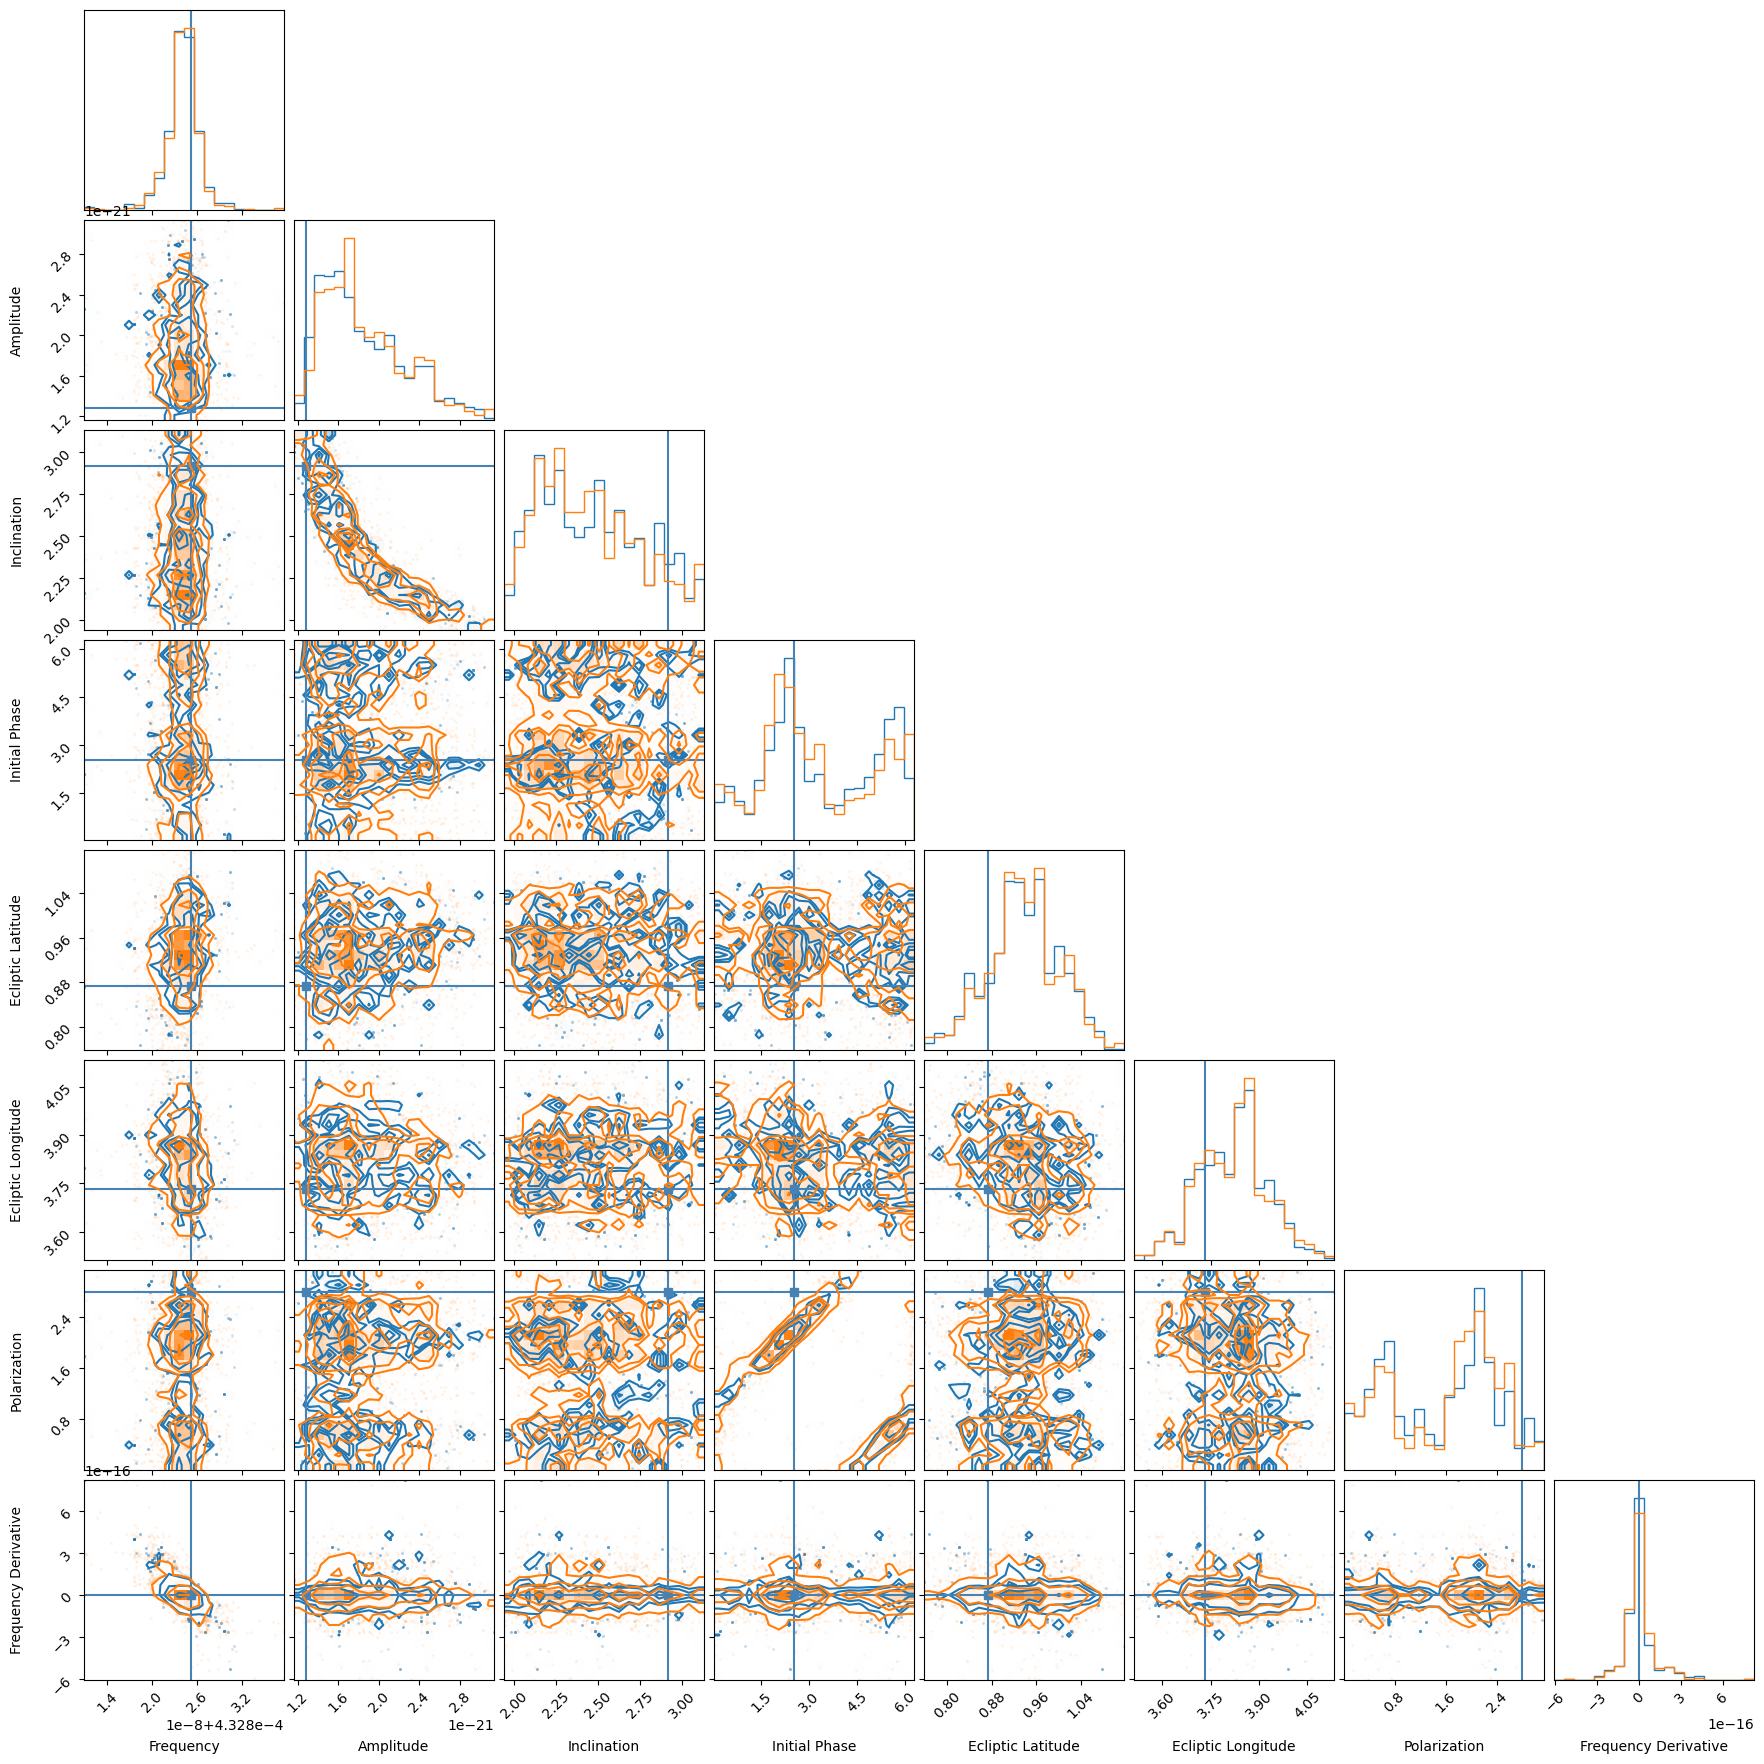

In [12]:
fig = corner.corner(samples, labels=binary_parameters, truths=injection_params[0], color='C0', hist_kwargs={'density': True})
corner.corner(np.asarray(flow_samples), labels=binary_parameters, fig=fig, color='C1', hist_kwargs={'density': True})
plt.show()